# Task 1 — ResNet50 on Cats vs Dogs

**Goal.** Build a cat-vs-dog classifier from only 1000 training images by fine-tuning
a ResNet50 pretrained on ImageNet, and measure how much of the network we should
let adapt.

**Four settings compared:**
1. **freeze_all** — freeze the whole backbone, train only a new 2-way head
2. **unfreeze_layer4** — also let the last block adapt
3. **unfreeze_layer3_4** — let the last two blocks adapt
4. **scratch** — same architecture, random weights, no pretraining (baseline)

**Data.** 500+500 train, 250+250 validation, 250+250 test, non-overlapping splits.

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from datasets import load_dataset
from PIL import Image

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/Users/bartox/Desktop/dev/ML/assignment6/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cpu


In [2]:
ds = load_dataset("microsoft/cats_vs_dogs", split="train")
class_names = ds.features["labels"].names
labels = ds["labels"]

by_class = {i: [] for i in range(len(class_names))}
for idx, y in enumerate(labels):
    by_class[y].append(idx)

rng = random.Random(42)
for i in by_class:
    rng.shuffle(by_class[i])

splits = {"train": 500, "val": 250, "test": 250}
root = Path("data")
if root.exists():
    shutil.rmtree(root)

cursor = {i: 0 for i in by_class}

def save_n(split, class_idx, n):
    out_dir = root / split / class_names[class_idx]
    out_dir.mkdir(parents=True, exist_ok=True)
    saved = 0
    while saved < n and cursor[class_idx] < len(by_class[class_idx]):
        idx = by_class[class_idx][cursor[class_idx]]
        cursor[class_idx] += 1
        try:
            ds[idx]["image"].convert("RGB").save(out_dir / f"{idx}.jpg")
            saved += 1
        except Exception:
            continue
    return saved

for split, n in splits.items():
    for class_idx in by_class:
        print(split, class_names[class_idx], save_n(split, class_idx, n))

train cat 500
train dog 500
val cat 250
val dog 250
test cat 250
test dog 250


In [3]:
import ssl, certifi, os
os.environ["SSL_CERT_FILE"] = certifi.where()
ssl._create_default_https_context = ssl.create_default_context

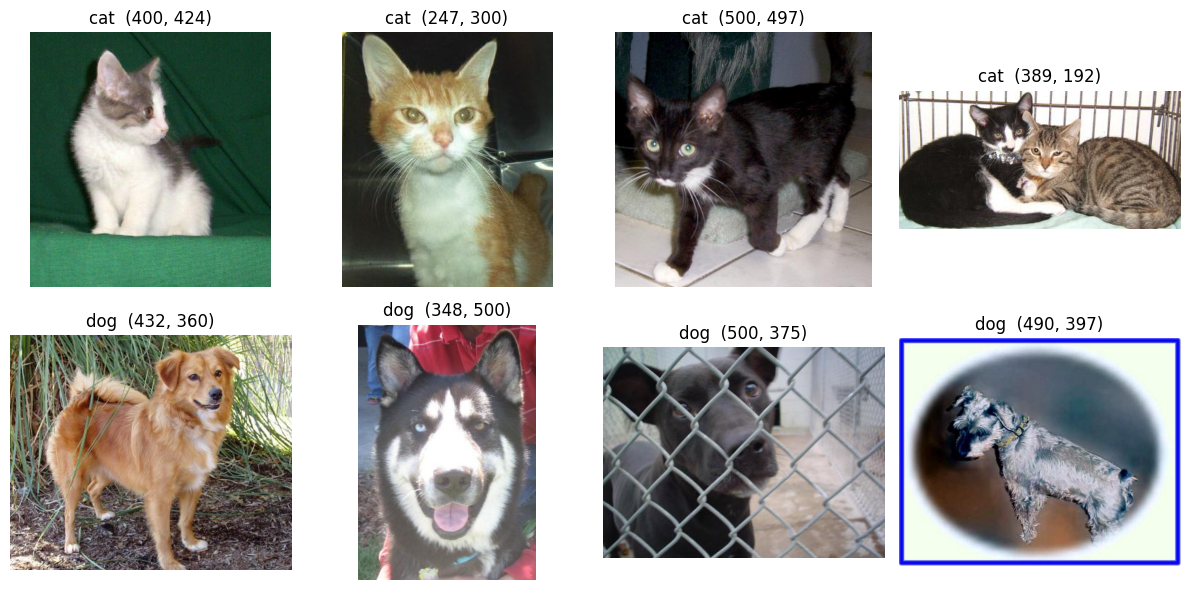

In [4]:
train_dir = Path("data/train")
n_per_class = 4
classes = sorted(p.name for p in train_dir.iterdir())

fig, axes = plt.subplots(len(classes), n_per_class, figsize=(3 * n_per_class, 6))

for row, cls in enumerate(classes):
    files = sorted((train_dir / cls).iterdir())[:n_per_class]
    for col, f in enumerate(files):
        img = Image.open(f)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{cls}  {img.size}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [5]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_ds = datasets.ImageFolder("data/train", transform=train_tf)
val_ds = datasets.ImageFolder("data/val", transform=eval_tf)
test_ds = datasets.ImageFolder("data/test", transform=eval_tf)

batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

print(train_ds.classes, train_ds.class_to_idx)
print(len(train_ds), len(val_ds), len(test_ds))

['cat', 'dog'] {'cat': 0, 'dog': 1}
1000 500 500


Each model replaces ResNet50's original 1000-class head with a new linear layer mapping 2048 features to 2 classes. Freezing is done per block by setting requires_grad to False, which means frozen layers still run on every image but their weights never change, so only the unfrozen parts learn. Training uses cross-entropy loss, the Adam optimizer, and a small learning rate of 1e-4 for the pretrained settings and 1e-3 for the scratch baseline, since random weights need larger steps. We keep the weights from the epoch with the lowest validation loss and apply early stopping. All configs share the same seed, so differences come from the freezing choice rather than random luck.

In [6]:
def build_model(unfreeze=None, pretrained=True):
    unfreeze = unfreeze or []
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)

    for p in model.parameters():
        p.requires_grad = False

    for name in unfreeze:
        block = getattr(model, name)
        for p in block.parameters():
            p.requires_grad = True

    model.fc = nn.Linear(2048, 2)

    if not pretrained:
        for p in model.parameters():
            p.requires_grad = True

    return model.to(device)

In [7]:
def count_trainable(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total

for cfg in [[], ["layer4"], ["layer3", "layer4"]]:
    m = build_model(unfreeze=cfg)
    tr, tot = count_trainable(m)
    print(cfg, f"{tr:,} / {tot:,} trainable")

m = build_model(pretrained=False)
tr, tot = count_trainable(m)
print("scratch", f"{tr:,} / {tot:,} trainable")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/bartox/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 48.3MB/s]


[] 4,098 / 23,512,130 trainable
['layer4'] 14,968,834 / 23,512,130 trainable
['layer3', 'layer4'] 22,067,202 / 23,512,130 trainable
scratch 23,512,130 / 23,512,130 trainable


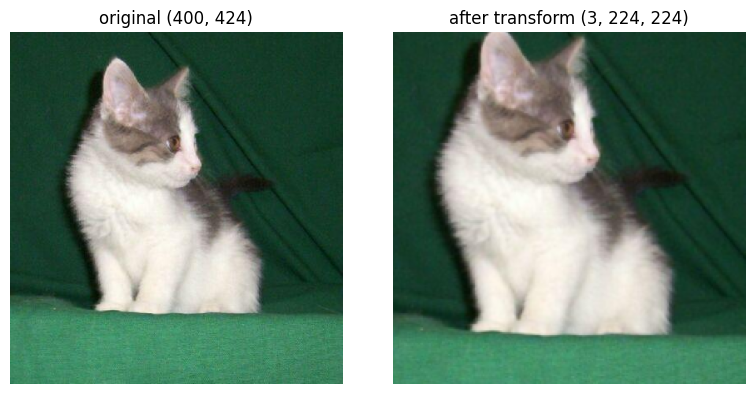

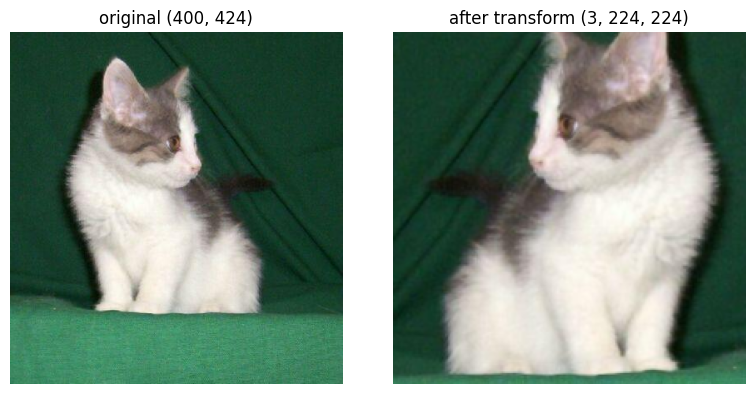

In [ ]:
inv_mean = [-m/s for m, s in zip(imagenet_mean, imagenet_std)]
inv_std = [1/s for s in imagenet_std]
denorm = transforms.Normalize(inv_mean, inv_std)

def show_pair(dataset_path, cls, idx, tf):
    from PIL import Image
    files = sorted((Path(dataset_path) / cls).iterdir())
    raw = Image.open(files[idx]).convert("RGB")
    tensor = tf(raw)
    shown = denorm(tensor).clamp(0, 1).permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(raw); ax[0].set_title(f"original {raw.size}"); ax[0].axis("off")
    ax[1].imshow(shown); ax[1].set_title(f"after transform {tuple(tensor.shape)}"); ax[1].axis("off")
    plt.tight_layout(); plt.show()

show_pair("data/train", "cat", 0, eval_tf)
show_pair("data/train", "cat", 0, train_tf)

In [ ]:
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

def fit(model, train_loader, val_loader, epochs=15, lr=1e-4, patience=4):
    criterion = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(params, lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

        train_loss, train_acc = total_loss / total, correct / total
        val_loss, val_acc = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"epoch {epoch+1:2d}  train_loss {train_loss:.3f}  train_acc {train_acc:.3f}  val_loss {val_loss:.3f}  val_acc {val_acc:.3f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_weights)
    return history

In [ ]:
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [11]:
configs = {
    "freeze_all":        dict(unfreeze=[],                   pretrained=True,  lr=1e-4),
    "unfreeze_layer4":   dict(unfreeze=["layer4"],           pretrained=True,  lr=1e-4),
    "unfreeze_layer3_4": dict(unfreeze=["layer3", "layer4"], pretrained=True,  lr=1e-4),
    "scratch":           dict(unfreeze=[],                   pretrained=False, lr=1e-3),
}

if device.type == "cpu":
    epochs, patience = 6, 3
else:
    epochs, patience = 15, 4

results = {}
for name, cfg in configs.items():
    print(f"\n=== {name} ===")
    set_seed(42)
    model = build_model(unfreeze=cfg["unfreeze"], pretrained=cfg["pretrained"])
    history = fit(model, train_loader, val_loader, epochs=epochs, lr=cfg["lr"], patience=patience)
    test_loss, test_acc = evaluate(model, test_loader)
    print(f"{name}  test_acc {test_acc:.3f}")
    results[name] = {"history": history, "test_loss": test_loss, "test_acc": test_acc}


=== freeze_all ===
epoch  1  train_loss 0.667  train_acc 0.601  val_loss 0.597  val_acc 0.856
epoch  2  train_loss 0.576  train_acc 0.818  val_loss 0.510  val_acc 0.948
epoch  3  train_loss 0.509  train_acc 0.875  val_loss 0.440  val_acc 0.964
epoch  4  train_loss 0.458  train_acc 0.897  val_loss 0.390  val_acc 0.966
epoch  5  train_loss 0.417  train_acc 0.913  val_loss 0.359  val_acc 0.966
epoch  6  train_loss 0.381  train_acc 0.920  val_loss 0.323  val_acc 0.970
epoch  7  train_loss 0.351  train_acc 0.918  val_loss 0.289  val_acc 0.972
epoch  8  train_loss 0.334  train_acc 0.924  val_loss 0.260  val_acc 0.974
epoch  9  train_loss 0.325  train_acc 0.917  val_loss 0.251  val_acc 0.968
epoch 10  train_loss 0.294  train_acc 0.933  val_loss 0.232  val_acc 0.976
epoch 11  train_loss 0.291  train_acc 0.920  val_loss 0.214  val_acc 0.980
epoch 12  train_loss 0.274  train_acc 0.933  val_loss 0.200  val_acc 0.978
epoch 13  train_loss 0.263  train_acc 0.929  val_loss 0.190  val_acc 0.978
epoch

All three pretrained settings reach 96 to 99 percent test accuracy, while training from scratch reaches only 56.4 percent, which is barely above the 50 percent of random guessing. On 1000 images, the ImageNet features are the difference between a working classifier and a coin flip, and that gap is the main result rather than the ordering among the pretrained settings. Among those three the differences are small, around 2 points on 500 test images, which is partly noise. Letting the late blocks adapt edges out freezing everything: the validation loss drops to about 0.02 for the unfrozen settings versus 0.18 for freeze_all, so all three are similarly accurate but the ones allowed to re-tune visual features are more confident. In this run unfreeze_layer3_4 was best at 0.990 test accuracy, but with a different seed it could swap places with unfreeze_layer4.

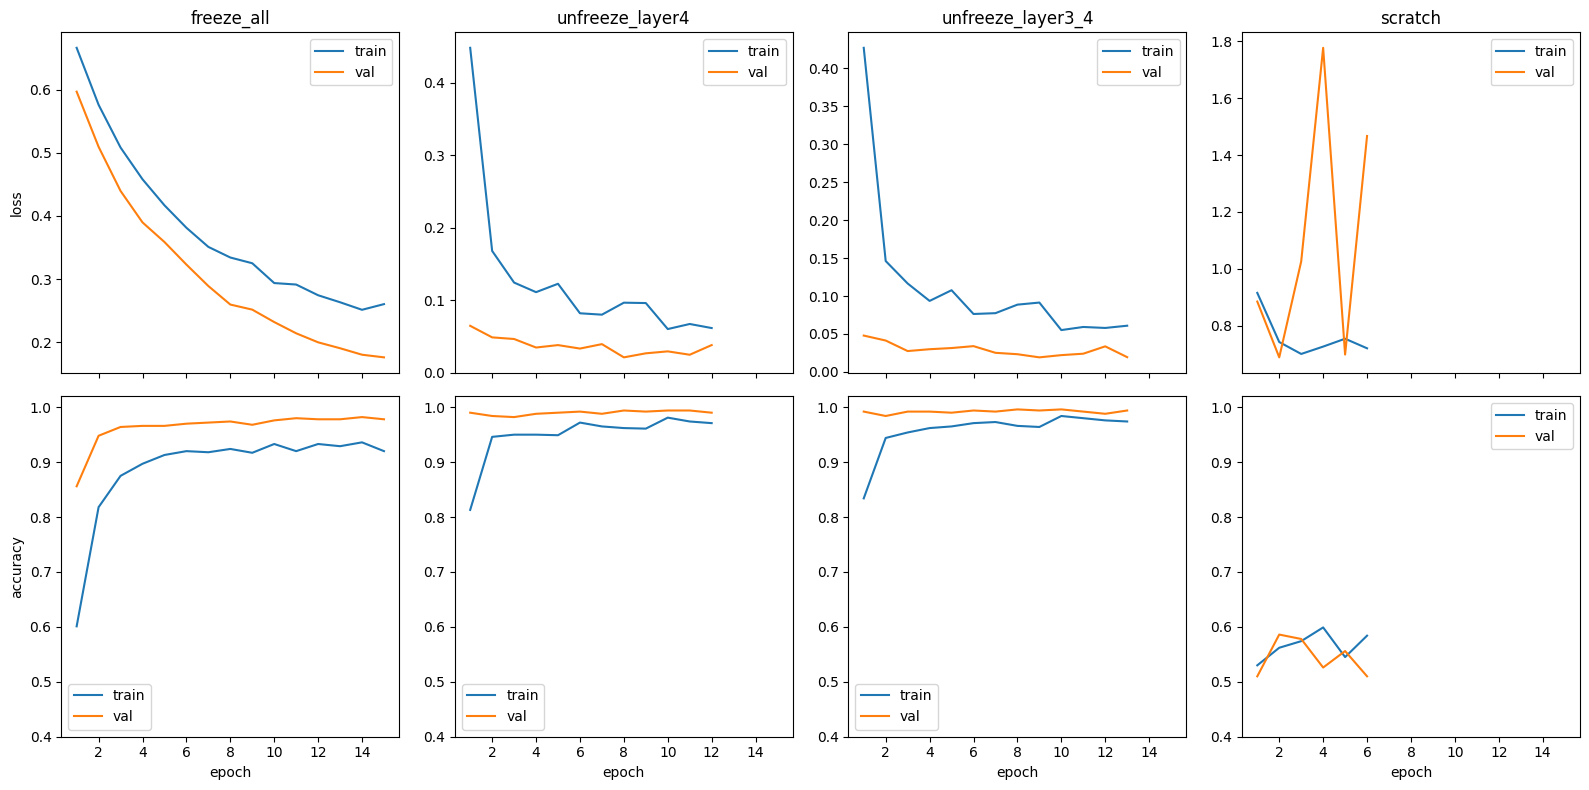

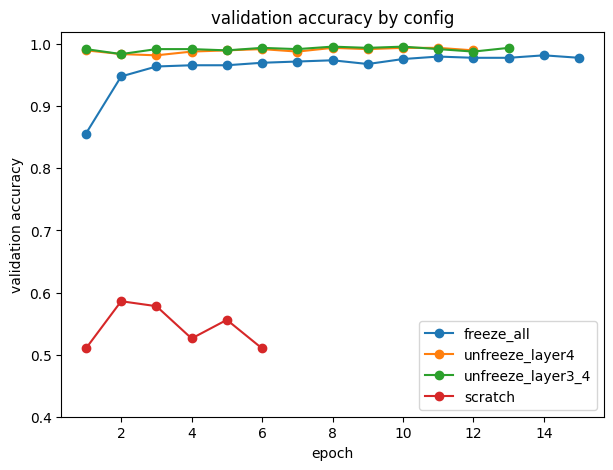

In [12]:
n = len(results)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8), sharex=True)

for col, (name, r) in enumerate(results.items()):
    h = r["history"]
    ep = range(1, len(h["train_loss"]) + 1)

    axes[0, col].plot(ep, h["train_loss"], label="train")
    axes[0, col].plot(ep, h["val_loss"], label="val")
    axes[0, col].set_title(name)
    axes[0, col].legend()
    if col == 0:
        axes[0, col].set_ylabel("loss")

    axes[1, col].plot(ep, h["train_acc"], label="train")
    axes[1, col].plot(ep, h["val_acc"], label="val")
    axes[1, col].set_xlabel("epoch")
    axes[1, col].set_ylim(0.4, 1.02)
    axes[1, col].legend()
    if col == 0:
        axes[1, col].set_ylabel("accuracy")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
for name, r in results.items():
    h = r["history"]
    plt.plot(range(1, len(h["val_acc"]) + 1), h["val_acc"], marker="o", label=name)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.ylim(0.4, 1.02)
plt.legend()
plt.title("validation accuracy by config")
plt.show()

In [13]:
header = f"{'config':<20}{'best_val_loss':>15}{'test_acc':>12}"
print(header)
print("-" * len(header))
for name, r in results.items():
    best_val = min(r["history"]["val_loss"])
    print(f"{name:<20}{best_val:>15.3f}{r['test_acc']:>12.3f}")

config                best_val_loss    test_acc
-----------------------------------------------
freeze_all                    0.176       0.966
unfreeze_layer4               0.021       0.986
unfreeze_layer3_4             0.019       0.990
scratch                       0.689       0.564


Training from scratch fails because ResNet50 has about 23.5 million parameters and, starting from random weights on only 1000 images, it has nothing to build on and cannot learn general visual features from so little data. Its validation loss never settles and even spikes above 1.0 across epochs, which is a model thrashing rather than converging. Freezing works because the pretrained backbone already computes useful features, so the task becomes learning a 2-way decision on top of fixed features, which means fitting only a few thousand head parameters and is easy and resistant to overfitting on a small dataset. Unfreezing the last block or two lets the most task-specific features re-tune toward cats and dogs, which helped here, while pushing further would add trainable parameters and overfitting risk that early stopping and validation-loss selection are there to control.

Overall, transfer learning is decisive when data is scarce: every pretrained variant beat the from-scratch baseline by roughly 40 percentage points. The best result came from letting the late blocks adapt, at 0.990 test accuracy, but freezing the entire backbone was already strong at 0.966 with far fewer trainable parameters.